In [ ]:
#imports
import numpy as np
import pandas as pd

# Make results reproducible
np.random.seed(7911)

n_policies = 10000

In [20]:
portfolio = pd.DataFrame({
    "policy_id": np.arange(1, n_policies + 1),

    "issue_age": np.random.randint(20, 71, n_policies),

    "gender": np.random.choice(
        ["Male", "Female"],
        n_policies,
        p=[0.52, 0.48]
    ),

    "policy_duration": np.random.randint(1, 31, n_policies)
})

In [21]:
portfolio["attained_age"] = (
    portfolio["issue_age"] + portfolio["policy_duration"]
)

In [ ]:


portfolio["gender"].value_counts()

gender
Male      5254
Female    4746
Name: count, dtype: int64

<Axes: >

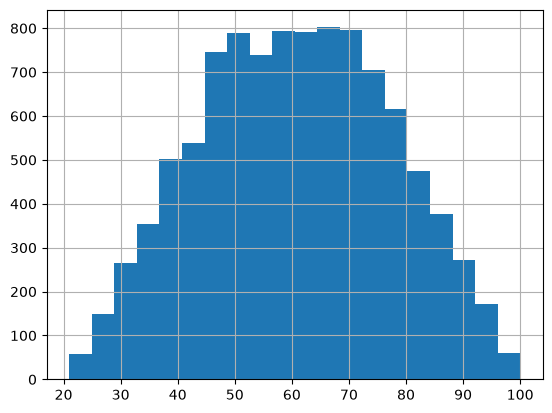

In [ ]:


portfolio["attained_age"].hist(bins=20)

In [5]:
portfolio.groupby("gender")["attained_age"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,4746.0,60.465445,16.850091,21.0,48.0,61.0,73.0,100.0
Male,5254.0,60.975828,16.971583,21.0,48.0,61.0,74.0,100.0


In [6]:
life_table_f = pd.read_excel("../data/raw/PerLifeTables_F_Hist_TR2023.xlsx", skiprows = 4)
life_table_m = pd.read_excel("../data/raw/PerLifeTables_M_Hist_TR2023.xlsx",skiprows = 4)

In [22]:
# Cleaning the table
female_2020 = life_table_f[life_table_f["Year"] == 2020].copy()
male_2020 = life_table_m[life_table_m["Year"] == 2020].copy()

female_2020 = female_2020[["x", "q(x)"]]
male_2020 = male_2020[["x", "q(x)"]]

female_2020 = female_2020.rename(columns={
    "x": "attained_age",
    "q(x)": "qx"
})

male_2020 = male_2020.rename(columns={
    "x": "attained_age",
    "q(x)": "qx"
})

female_2020["gender"] = "Female"
male_2020["gender"] = "Male"

life_table = pd.concat(
    [female_2020, male_2020],
    ignore_index=True
)

portfolio = portfolio.merge(
    life_table,
    on=["gender", "attained_age"],
    how="left"
)

portfolio["expected_deaths"] = portfolio["qx"]

In [24]:
portfolio.sort_values("qx", ascending=False).head(10)

,policy_id,issue_age,gender,policy_duration,attained_age,qx,expected_deaths
4455,4456,70,Male,30,100,0.384967,0.384967
9056,9057,70,Male,30,100,0.384967,0.384967
6300,6301,69,Male,30,99,0.366635,0.366635
3832,3833,69,Male,30,99,0.366635,0.366635
1023,1024,70,Male,29,99,0.366635,0.366635
2650,2651,70,Male,29,99,0.366635,0.366635
383,384,70,Male,29,99,0.366635,0.366635
6053,6054,69,Male,30,99,0.366635,0.366635
898,899,68,Male,30,98,0.349177,0.349177
8850,8851,68,Male,30,98,0.349177,0.349177


In [25]:
portfolio["death"] = np.random.binomial(
    n=1,
    p=portfolio["qx"]
)

In [26]:
portfolio["death"].sum()


np.int64(328)

In [27]:
portfolio["qx"].sum()

np.float64(307.145317)

In [28]:
ae_ratio = portfolio["death"].sum() / portfolio["qx"].sum()

In [29]:
portfolio.groupby("attained_age").agg({
    "expected_deaths": "sum",
    "death": "sum"
})

,expected_deaths,death
attained_age,,
21,0.008153,0
22,0.018636,0
23,0.024055,0
24,0.035812,0
25,0.054852,0
...,...,...
96,10.339220,10
97,7.422491,7
98,5.465624,3


In [30]:
experience = (
    portfolio
    .groupby("attained_age")
    .agg(
        expected_deaths=("expected_deaths", "sum"),
        actual_deaths=("death", "sum"),
        exposure=("policy_id", "count")
    )
    .reset_index()
)

experience["AE"] = (
    experience["actual_deaths"] /
    experience["expected_deaths"]
)

experience.head()

,attained_age,expected_deaths,actual_deaths,exposure,AE
0,21,0.008153,0,6,0.0
1,22,0.018636,0,18,0.0
2,23,0.024055,0,20,0.0
3,24,0.035812,0,28,0.0
4,25,0.054852,0,45,0.0


In [31]:
#Group ages into bands to make AE ratio more interpretible
bins = [20, 30, 40, 50, 60, 70, 80, 90, 101]
labels = [
    "20–29",
    "30–39",
    "40–49",
    "50–59",
    "60–69",
    "70–79",
    "80–89",
    "90–100"
]

portfolio["age_band"] = pd.cut(
    portfolio["attained_age"],
    bins=bins,
    labels=labels,
    right=False
)

band_experience = (
    portfolio
    .groupby("age_band")
    .agg(
        exposure=("policy_id", "count"),
        expected=("expected_deaths", "sum"),
        actual=("death", "sum")
    )
)

band_experience["AE"] = (
    band_experience["actual"] /
    band_experience["expected"]
)

band_experience

,exposure,expected,actual,AE
age_band,,,,
20–29,309,0.419729,0,0.000000
30–39,942,1.917450,5,2.607630
40–49,1586,5.403437,7,1.295472
50–59,1970,14.180760,13,0.916735
60–69,1937,29.390431,38,1.292938
70–79,1723,56.838792,61,1.073211
80–89,1107,101.564691,112,1.102745
90–100,426,97.430027,92,0.944267
